In [1]:
import re
import numpy as np
import pandas as pd

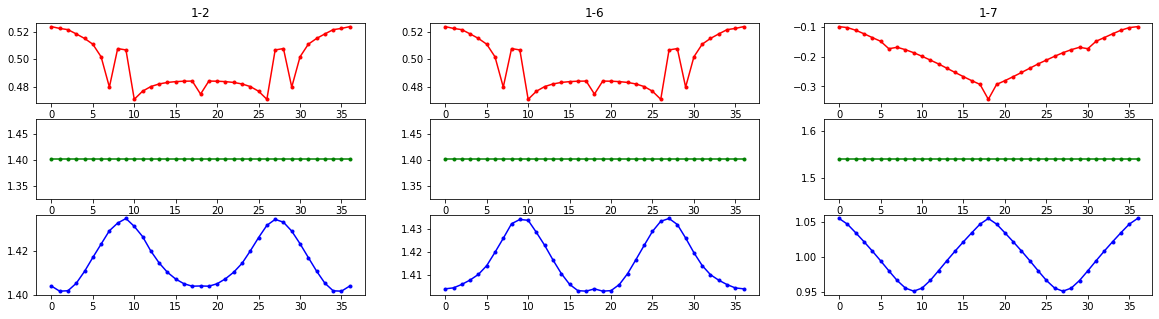

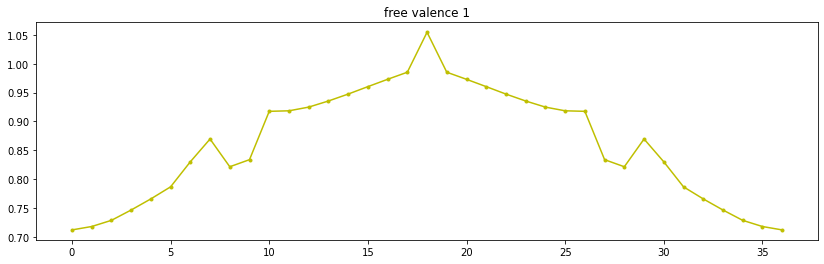

In [2]:
# 联苯键级键角图
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def get_wfnOrders(atom1,atom2):
    with open(r"C:\code\HFV\files\benScan\benScanMfn.txt",'r',encoding='utf-8') as f:
        data=f.read()
    wfnOrders=re.findall(r'# +\d: +'+f'{atom1}'+'\(C \)    '+f'{atom2}'+'\(C \) +(\d.\d{8})',data)
    wfnOrders=np.array(wfnOrders,dtype=np.float32)
    return wfnOrders
def get_bondOrders(atom1,atom2):
    with open(r"RES13.txt",'r',encoding='utf-8') as f:
        data=f.read()
    datas=data.split('----------------------------------------------------------------------')[1:]
    all_res=[]
    all_valence=[]
    for each in datas:
        res=re.search(f'{atom1}->{atom2}'+r',bond order:(-?\d.\d{4}),bond length:(-?\d.\d{4})',each)
        valence=re.search(r'free valence:(-?\d.\d{4})',each).groups()
        if res is not None:
            all_res.append(res.groups())
        else:
            all_res.append([0,0])
        all_valence.append(valence)
    bondOrders=pd.DataFrame(all_res,dtype=float).to_numpy()[:,0]
    bondLengths=pd.DataFrame(all_res,dtype=float).to_numpy()[:,1]
    atomValence=pd.DataFrame(all_valence,dtype=float).to_numpy().flatten()
    return bondOrders,bondLengths,atomValence
fig,a=plt.subplots(3,3,figsize=(20, 5))
arounds=[2,6,7]
for i in range(3):
    around=arounds[i]
    bondOrders,bondLengths,atomValence=get_bondOrders(1,around)
    a[0][i].set_title(f'1-{around}')
    # a[0][i].plot(np.arange(len(atomValence)),atomValence,'y.-')
    a[0][i].plot(np.arange(len(bondOrders)),bondOrders,'r.-')
    a[1][i].plot(np.arange(len(bondLengths)),bondLengths,'g.-')
    wfnOrders=get_wfnOrders(1,around)
    a[2][i].plot(np.arange(len(wfnOrders)),wfnOrders,'b.-')
# a[0].plot(np.arange(len(atomValence)),atomValence[::-1],'y.-')
# a[1].plot(np.arange(len(bondOrders)),bondOrders[::-1],'r.-')
# a[2].plot(np.arange(len(bondLengths)),bondLengths[::-1],'g.-')
# a[3].plot(np.arange(len(wfnOrders)),wfnOrders[::-1],'b.-')
fig,a=plt.subplots(figsize=(14, 4))
a.set_title('free valence 1')
a.plot(np.arange(len(atomValence)),atomValence,'y.-')